In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "transactions.csv"

# Load the latest version
transactions = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sergionefedov/fraud-detection-1m-transactions-7-fraud-types",
  file_path,
)

/tmp/ipykernel_2352/490069966.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  transactions = kagglehub.load_dataset(


100%|██████████| 122M/122M [00:00<00:00, 175MB/s]


## Importation des bibliothèques

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Inspection des données

In [ ]:
transactions.head()

,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,...,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud,fraud_pattern
0,TXN000000001,ACC0016173,2023-02-21 08:02:38,8,1,0,168.42,travel,4511,CA,...,53.2,1,21,3,2.6423,3256,1,3958.46,0,NaN
1,TXN000000002,ACC0011196,2024-05-12 23:13:34,23,6,1,85.78,online_retail,5999,AU,...,25.3,1,234,1,0.7279,1527,1,3553.35,0,NaN
2,TXN000000003,ACC0001181,2023-09-22 23:28:21,23,4,0,20.15,pharmacy,5912,CA,...,21.3,1,85,1,0.1851,2230,1,4362.57,0,NaN
3,TXN000000004,ACC0037105,2022-09-28 23:26:38,23,2,0,62.49,grocery,5411,US,...,13.7,0,98,0,1.5223,1863,1,3194.84,0,NaN
4,TXN000000005,ACC0028471,2023-02-23 17:54:13,17,3,0,71.68,online_retail,5999,US,...,9.7,0,721,2,0.7724,1728,0,11850.06,0,NaN


Les cinq premières lignes du DataFrame `transactions` sont affichées, donnant un aperçu des colonnes et des types de données. Nous pouvons voir des informations telles que l'ID de transaction, l'ID de compte, l'horodatage, le montant, la catégorie de marchand, le pays du marchand, le score de risque IP, et un indicateur de fraude (`is_fraud`).

In [ ]:
transactions.shape

(1000000, 23)

Le DataFrame `transactions` contient 1 000 000 d'entrées (lignes) et 23 colonnes, ce qui représente un ensemble de données substantiel pour l'analyse.

In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 23 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   transaction_id       1000000 non-null  object 
 1   account_id           1000000 non-null  object 
 2   timestamp            1000000 non-null  object 
 3   hour_of_day          1000000 non-null  int64  
 4   day_of_week          1000000 non-null  int64  
 5   is_weekend           1000000 non-null  int64  
 6   amount               1000000 non-null  float64
 7   merchant_category    1000000 non-null  object 
 8   mcc_code             1000000 non-null  int64  
 9   merchant_country     1000000 non-null  object 
 10  card_present         1000000 non-null  int64  
 11  device_type          1000000 non-null  object 
 12  device_known         1000000 non-null  int64  
 13  ip_risk_score        1000000 non-null  float64
 14  is_foreign_txn       1000000 non-null  int64  
 15 

Le DataFrame comprend 23 colonnes avec différents types de données (int64, float64, object). La plupart des colonnes ont 1 000 000 d'entrées non nulles, indiquant une complétude élevée des données, à l'exception de `fraud_pattern` qui contient des valeurs manquantes. `timestamp` est un objet et devra probablement être converti en datetime pour les analyses temporelles.

### Statistiques Descriptives

In [ ]:
transactions.describe()

,hour_of_day,day_of_week,is_weekend,amount,mcc_code,card_present,device_known,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,11.494197,3.003311,0.287152,183.738264,5703.713286,0.350654,0.892337,21.605828,0.294417,180.112610,1.050421,3.298512,1833.588908,0.647567,6706.938185,0.017143
std,6.920962,2.002666,0.452433,316.693903,548.917957,0.477175,0.309954,16.269652,0.455780,180.148636,1.095055,7.157055,1046.489932,0.477728,6174.164106,0.129804
min,0.000000,0.000000,0.000000,1.830000,4511.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.011800,30.000000,0.000000,500.000000,0.000000
25%,5.000000,1.000000,0.000000,43.480000,5411.000000,0.000000,1.000000,8.500000,0.000000,52.000000,0.000000,0.597100,926.000000,0.000000,2833.750000,0.000000
50%,11.000000,3.000000,0.000000,81.140000,5734.000000,0.000000,1.000000,18.700000,0.000000,125.000000,1.000000,1.285300,1832.000000,1.000000,4880.100000,0.000000
75%,17.000000,5.000000,1.000000,189.760000,5999.000000,1.000000,1.000000,30.700000,1.000000,250.000000,2.000000,3.155500,2738.000000,1.000000,8384.040000,0.000000
max,23.000000,6.000000,1.000000,25000.000000,7995.000000,1.000000,1.000000,100.000000,1.000000,2733.000000,15.000000,945.537100,3649.000000,1.000000,50000.000000,1.000000


Les statistiques descriptives des colonnes numériques montrent la distribution des données. Par exemple, le montant des transactions varie de 1.83 à 25000 avec une moyenne de 183.74. La colonne `is_fraud` indique que seulement environ 1.71% des transactions sont frauduleuses, ce qui souligne un déséquilibre de classe important.

In [ ]:
columns = transactions.columns

for column in columns:
    if transactions[column].dtype.name in ["object"]:
        print(f"{column} : {transactions[column].nunique()}")

transaction_id : 1000000
account_id : 49903
timestamp : 994753
merchant_category : 14
merchant_country : 11
device_type : 5
fraud_pattern : 7


### Cardinalité des Variables Catégorielles
Les colonnes `transaction_id` et `timestamp` ont une cardinalité très élevée, presque unique pour chaque entrée, ce qui est attendu. `account_id` a également une cardinalité élevée, tandis que des colonnes comme `merchant_category`, `merchant_country`, `device_type`, et `fraud_pattern` ont un nombre limité de valeurs uniques, ce qui les rend adaptées à l'encodage catégoriel. La colonne `fraud_pattern` avec 7 valeurs uniques et des NaN indique les différents types de fraude enregistrés.

### Suppression des Colonnes Identifiantes et du Type de Fraude


In [ ]:
transactions = transactions.drop(columns=["transaction_id", "account_id", "timestamp", "fraud_pattern"])

In [ ]:
transactions.head()

,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,card_present,device_type,device_known,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud
0,8,1,0,168.42,travel,4511,CA,0,mobile_app,1,53.2,1,21,3,2.6423,3256,1,3958.46,0
1,23,6,1,85.78,online_retail,5999,AU,0,web_browser,1,25.3,1,234,1,0.7279,1527,1,3553.35,0
2,23,4,0,20.15,pharmacy,5912,CA,0,web_browser,1,21.3,1,85,1,0.1851,2230,1,4362.57,0
3,23,2,0,62.49,grocery,5411,US,0,mobile_app,1,13.7,0,98,0,1.5223,1863,1,3194.84,0
4,17,3,0,71.68,online_retail,5999,US,0,web_browser,1,9.7,0,721,2,0.7724,1728,0,11850.06,0


## Nettoyage

### Vérification des Valeurs Manquantes

In [ ]:
transactions.isnull().sum()

,0
hour_of_day,0
day_of_week,0
is_weekend,0
amount,0
merchant_category,0
mcc_code,0
merchant_country,0
card_present,0
device_type,0
device_known,0


Après l'élimination de la colonne `fraud_pattern`, il n'y a plus de valeurs manquantes dans le DataFrame. Toutes les colonnes restantes sont complètes, ce qui simplifie les étapes de prétraitement.

### Vérification des Doublons

In [ ]:
transactions.duplicated().sum()

np.int64(0)

Le DataFrame ne contient aucune ligne dupliquée, ce qui garantit l'unicité de chaque observation et évite tout biais potentiel dans l'analyse ou la modélisation dû à des entrées redondantes.

### Valeurs Uniques des Variables Catégorielles

In [ ]:
columns = transactions.columns

for column in columns:
    if transactions[column].dtype.name in ["object"]:
        print(f"{column} : {transactions[column].unique()} \n\n")

merchant_category : ['travel' 'online_retail' 'pharmacy' 'grocery' 'clothing' 'atm'
 'restaurant' 'gas_station' 'electronics' 'hotel' 'utilities'
 'money_transfer' 'crypto' 'gambling'] 


merchant_country : ['CA' 'AU' 'US' 'FR' 'NG' 'DE' 'RO' 'MX' 'CN' 'GB' 'BR'] 


device_type : ['mobile_app' 'web_browser' 'pos_terminal' 'phone_ivr' 'atm'] 




Cette cellule affiche les valeurs uniques pour chaque colonne de type 'object'. Cela confirme la nature discrète et le nombre de catégories pour `merchant_category`, `merchant_country`, et `device_type`. Ces informations sont cruciales pour l'encodage des caractéristiques catégorielles avant la modélisation.

## Analyse univariée

In [ ]:
num_cols = transactions.select_dtypes(include=np.number).columns
cat_cols = transactions.select_dtypes(include='object').columns

### Analyse Univariée des Variables Numériques

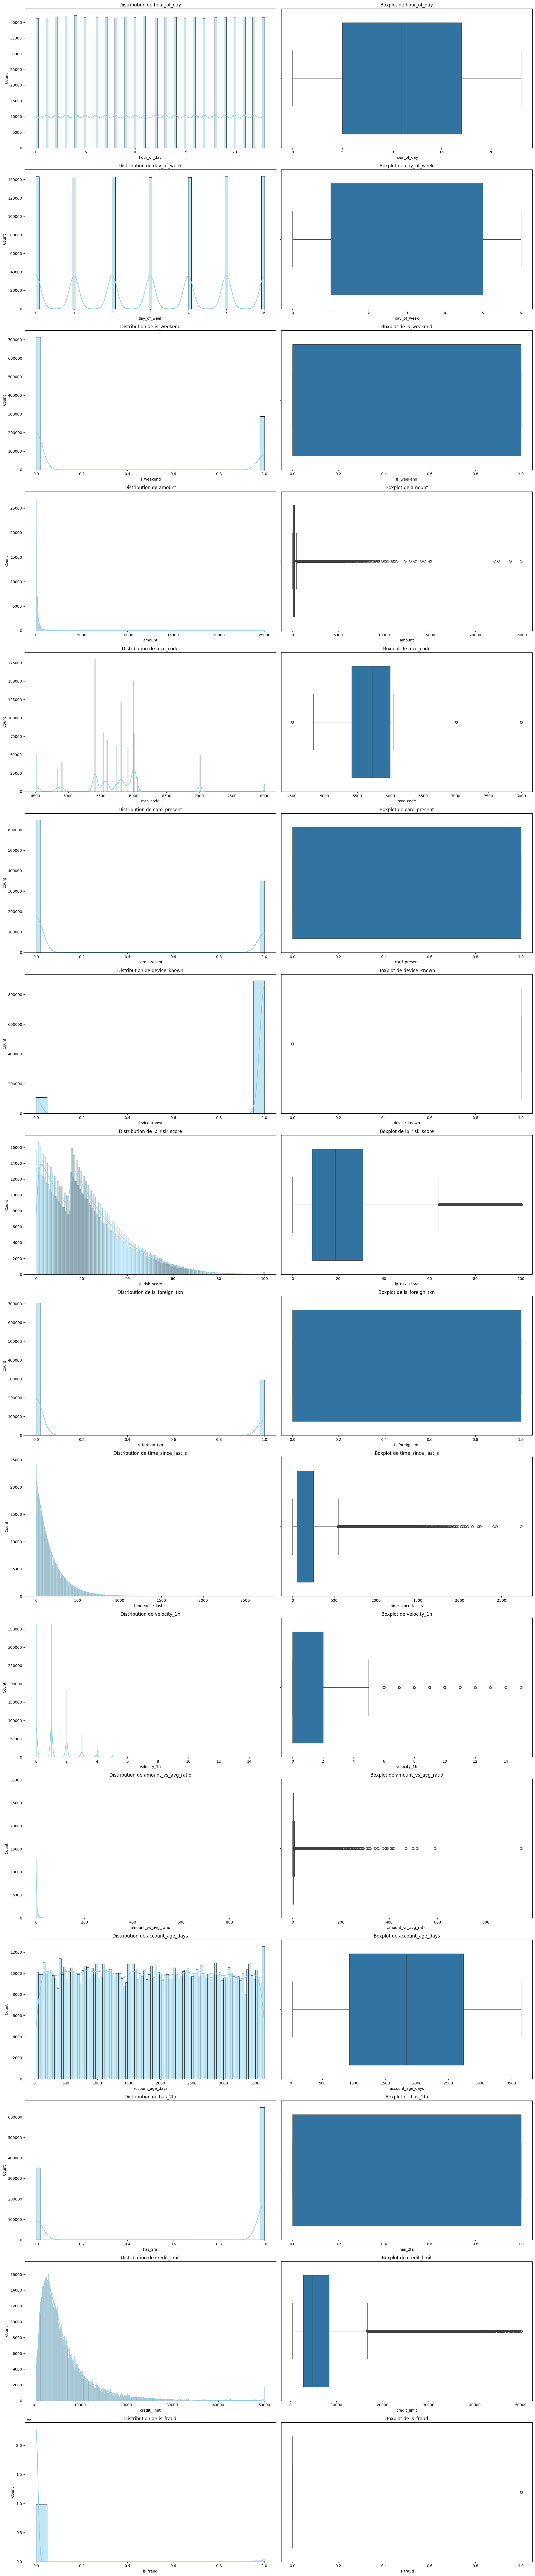

In [ ]:
plt.figure(figsize=(20, 6 * len(num_cols)))

for i, col in enumerate(num_cols):
  plt.subplot(len(num_cols), 2, i * 2 + 1)
  sns.histplot(transactions[col], kde=True, color="skyblue")
  plt.title(f"Distribution de {col}")

  plt.subplot(len(num_cols), 2, i * 2 + 2)
  sns.boxplot(x=transactions[col])
  plt.title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

Les histogrammes et les boxplots pour les variables numériques révèlent leur distribution. Certains histogrammes peuvent montrer des distributions asymétriques (par exemple, vers la droite pour `amount`, `velocity_1h`, `amount_vs_avg_ratio`), indiquant la présence de valeurs extrêmes ou une concentration des données à des valeurs plus faibles. Les boxplots aident à identifier la présence d'outliers et la dispersion des données.

### Analyse Univariée des Variables Catégorielles

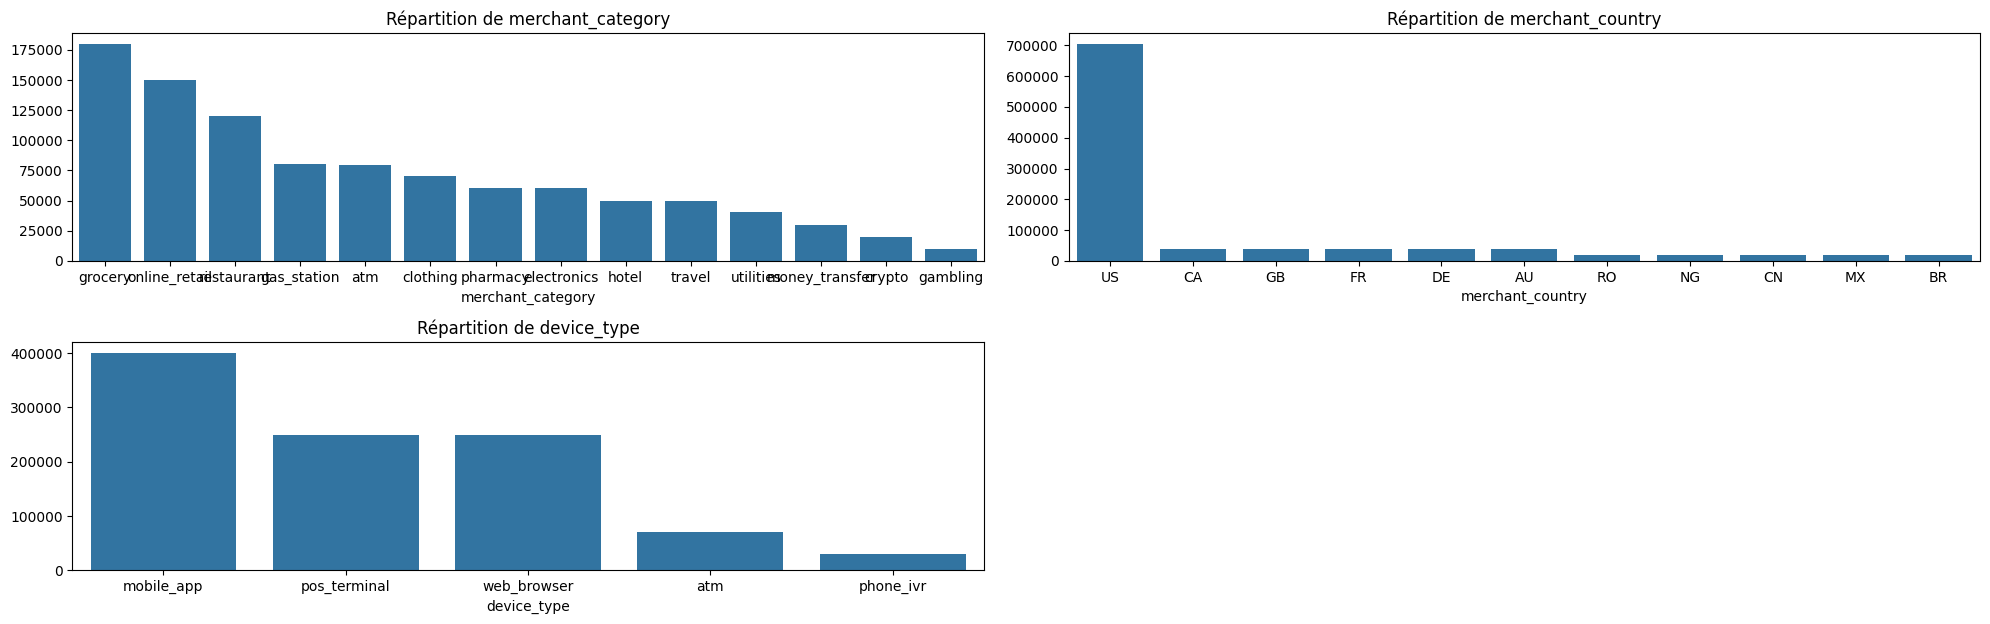

In [ ]:
plt.figure(figsize=(20, 6 * len(cat_cols)/2))

for i, col in enumerate(cat_cols):
  plt.subplot(len(cat_cols), 2, i + 1)
  sns.barplot(x=transactions[col].value_counts().index, y=transactions[col].value_counts().values)
  plt.title(f"Répartition de {col}")

plt.tight_layout()
plt.show()

Les graphiques à barres pour les variables catégorielles montrent la fréquence de chaque catégorie. Par exemple, nous pouvons voir quelles sont les `merchant_category`, `merchant_country`, et `device_type` les plus courantes. Ces visualisations sont utiles pour comprendre la composition de nos données catégorielles et identifier d'éventuelles catégories rares qui pourraient nécessiter un traitement spécial.

## Analyse bivariée

In [ ]:
#plt.figure(figsize=(20, 20))
#sns.pairplot(transactions, hue="is_fraud")
#plt.show()

### Matrice de Corrélation des Variables Numériques

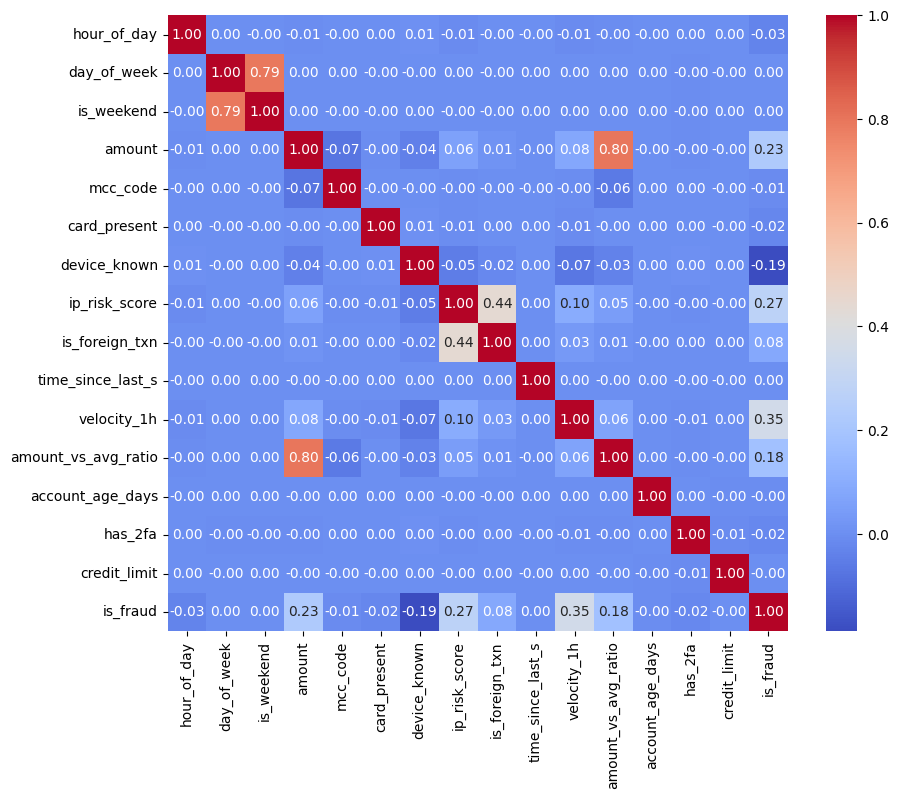

In [ ]:
corr_matrix = transactions[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

La heatmap de la matrice de corrélation visualise les relations linéaires entre les variables numériques. Des valeurs plus proches de 1 ou -1 indiquent des corrélations fortes positives ou négatives, respectivement. Une corrélation élevée entre des prédicteurs peut suggérer des problèmes de multicolinéarité pour certains modèles, tandis que des corrélations avec la variable cible (`is_fraud`) peuvent indiquer des caractéristiques importantes pour la prédiction.